# Fraud Detection & Risk Analysis (PaySim)

## Problem Statement
Detect fraudulent financial transactions and analyze risk patterns to reduce financial loss.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful")

Setup successful


In [3]:
import pandas as pd

df = pd.read_csv("paysim.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Data Understanding

- Dataset contains financial transactions
- Target variable: isFraud
- Dataset is highly imbalanced

## Exploratory Data Analysis

In [4]:
df.shape

(6362620, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

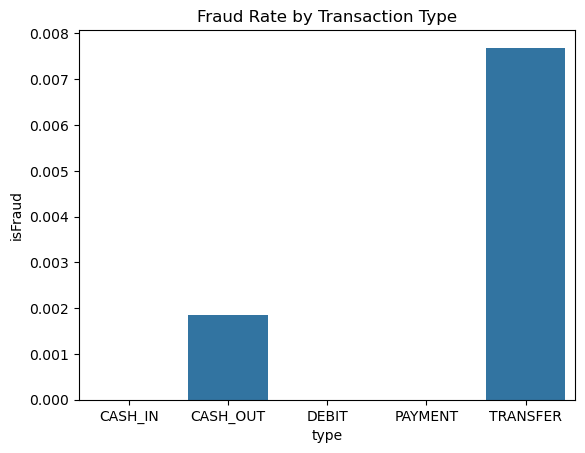

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fraud_type = df.groupby('type')['isFraud'].mean().reset_index()

sns.barplot(x='type', y='isFraud', data=fraud_type)
plt.title("Fraud Rate by Transaction Type")
plt.show()

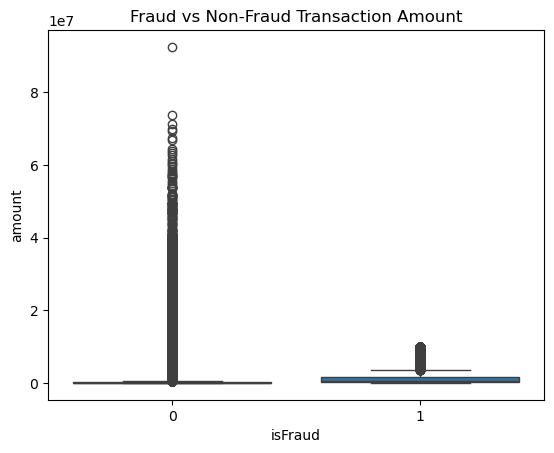

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Non-Fraud Transaction Amount")
plt.show()

## Key EDA Insights

- Fraud is rare (~0.13%)
- Fraud mainly occurs in TRANSFER and CASH_OUT
- Amount alone is not a strong indicator

## Feature Engineering

Created new features:
- errorOrig = oldbalanceOrg - newbalanceOrig - amount  
- errorDest = newbalanceDest - oldbalanceDest - amount  

These features capture balance inconsistencies, which strongly indicate fraudulent behavior.

In [13]:
df['errorOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['errorDest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

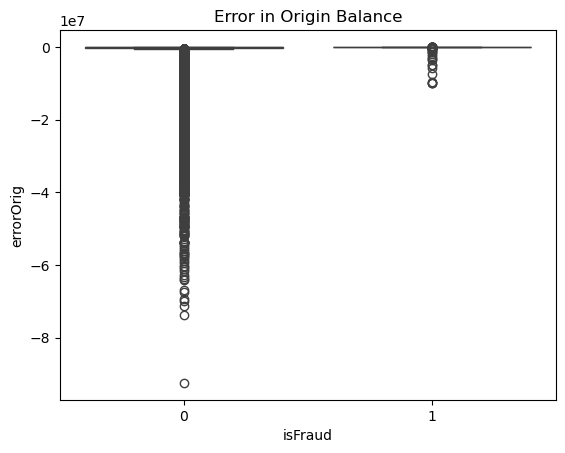

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='isFraud', y='errorOrig', data=df)
plt.title("Error in Origin Balance")
plt.show()

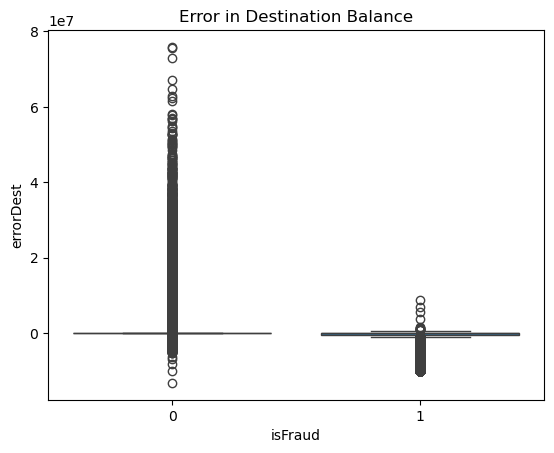

In [15]:
sns.boxplot(x='isFraud', y='errorDest', data=df)
plt.title("Error in Destination Balance")
plt.show()

In [16]:
features = ['amount', 'errorOrig', 'errorDest']

## Model Building

Using Logistic Regression with selected features:
- amount
- errorOrig
- errorDest

Data is split into training and testing sets.

In [17]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_train.shape, X_test.shape

((5090096, 3), (1272524, 3))

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.87      0.43      0.58      1620

    accuracy                           1.00   1272524
   macro avg       0.94      0.71      0.79   1272524
weighted avg       1.00      1.00      1.00   1272524



## Initial Model Performance

- Recall (fraud): 43%  
- Model struggled due to class imbalance  
- Many fraud cases were not detected  

In [23]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270904
           1       0.03      0.85      0.05      1620

    accuracy                           0.96   1272524
   macro avg       0.51      0.91      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524



## Improved Model Performance

- Recall (fraud): 85%  
- Precision decreased due to more false positives  
- Model now detects most fraud cases  

This trade-off is acceptable in fraud detection.

In [26]:
y_prob = model.predict_proba(X_test)[:, 1]

In [27]:
y_prob[:5]

array([1.30238940e-04, 2.32965385e-01, 6.88147023e-03, 7.97703589e-08,
       3.49780163e-02])

## Risk Scoring System

Predicted probabilities are converted into risk categories:
- Low Risk (< 0.2)  
- Medium Risk (0.2 – 0.6)  
- High Risk (> 0.6)  

This helps prioritize transactions for investigation.

In [28]:
def risk_level(p):
    if p < 0.2:
        return "Low"
    elif p < 0.6:
        return "Medium"
    else:
        return "High"

df_test = X_test.copy()
df_test['fraud_prob'] = y_prob
df_test['risk'] = df_test['fraud_prob'].apply(risk_level)

df_test[['fraud_prob', 'risk']].head()

,fraud_prob,risk
3737323,1.302389e-04,Low
264914,2.329654e-01,Medium
85647,6.881470e-03,Low
5899326,7.977036e-08,Low
2544263,3.497802e-02,Low


In [29]:
df_test['risk'].value_counts()

risk
Low       1007285
Medium     225434
High        39805
Name: count, dtype: int64

## Final Conclusion

A fraud detection system was developed using the PaySim dataset.

The model improved fraud detection recall from 43% to 85% after handling class imbalance.

A risk scoring system was implemented to classify transactions into Low, Medium, and High risk, enabling better fraud prevention and decision-making.